In [1]:
import torch
import time
import numpy as np

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

# 1. Base Model Preparation

In [2]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.float32
)

model = model.to("cpu")
model.eval()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(49152, 960, padding_idx=2)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=960, out_features=960, bias=False)
          (k_proj): Linear(in_features=960, out_features=320, bias=False)
          (v_proj): Linear(in_features=960, out_features=320, bias=False)
          (o_proj): Linear(in_features=960, out_features=960, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=960, out_features=2560, bias=False)
          (up_proj): Linear(in_features=960, out_features=2560, bias=False)
          (down_proj): Linear(in_features=2560, out_features=960, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((960,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((960,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((960,), eps=1e-05)
    (r

In [3]:
def generate_tool(model, tokenizer, user_prompt, max_new_tokens=180):
    messages = [{"role": "user", "content": user_prompt}]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_len:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

In [4]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

messages = [
    {"role": "user", "content": prompt}
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
)

inputs = {k: v.to(model.device) for k,v in inputs.items()} # This moves vectors to whatever device user is using

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=180,
        do_sample=False
    )
input_len = inputs["input_ids"].shape[1]
generated_ids = outputs[0][input_len:]
print(tokenizer.decode(generated_ids, skip_special_tokens=True))

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

3. Plan Trip:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

4. Check Weather:
- San Diego:
- 2026-05-10 to 2026-05-15
- Medium Budget

5. Search for Accommod


In [5]:
def benchmark_generate(model, tokenizer, messages, max_new_tokens=80, do_sample=False):
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )

    input_ids = inputs["input_ids"]
    input_len = input_ids.shape[1]

    start = time.perf_counter()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
        )

    end = time.perf_counter()

    generated_ids = outputs[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

    total_time_s = end - start
    generated_tokens = generated_ids.shape[0]
    tokens_per_second = generated_tokens / total_time_s if total_time_s > 0 else 0.0

    return {
        "text": generated_text,
        "total_time_s": total_time_s,
        "generated_tokens": generated_tokens,
        "tokens_per_second": tokens_per_second,
    }

In [6]:
result = benchmark_generate(
    model,
    tokenizer,
    messages,
    max_new_tokens=80,
    do_sample=False
)
print(result["text"])
print()
print(np.round(result["total_time_s"],2))
print(np.round(result["generated_tokens"],2))
print(np.round(result["tokens_per_second"],2))

Sure, here are the tools you requested:

1. Search Flights:
- San Diego to New York:
- 2026-05-10 to 2026-05-15
- Medium Budget

2. Search Hotels:
- San Diego:
- 2026-05-10 to 

3.5
80
22.84


# 2. LoRA Finetune 

In [7]:
from pathlib import Path

In [8]:
curr_dir = Path.cwd()
curr_dir.is_dir()

True

In [9]:
output_dir = curr_dir.parent/"outputs"/"models"
output_dir.is_dir()

True

In [10]:
[item for item in curr_dir.parent.iterdir()]

[WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.git'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.gitignore'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.python-version'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/.venv'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/LICENSE'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/main.py'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/notebooks'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/outputs'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/pyproject.toml'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/README.md'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-l

In [11]:
datasets_dir = curr_dir.parent/"datasets"/"structured_json"
datasets_dir.is_dir()

True

In [12]:
[item for item in datasets_dir.iterdir()]

[WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TEST_travel_tool_routing_20_samples.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TEST_travel_tool_routing_20_samples_prompted_v2.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TRAIN_travel_tool_routing_100_samples.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/VAL_travel_tool_routing_20_samples.jsonl'),
 WindowsPath('C:/Users/Derrick/OneDrive/Desktop/GIT/model-alignment-lab/datasets/structured_json/VAL_travel_tool_routing_20_samples_prompted_v2.jsonl')]

In [13]:
train_path = datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples_prompted_v2.jsonl") #datasets_dir.joinpath("TRAIN_travel_tool_routing_100_samples.jsonl")
train_path.is_file()

True

In [14]:
test_path = datasets_dir.joinpath("TEST_travel_tool_routing_20_samples_prompted_v2.jsonl")
test_path.is_file()

True

In [15]:
val_path = datasets_dir.joinpath("VAL_travel_tool_routing_20_samples_prompted_v2.jsonl")
val_path.is_file()

True

## Load the Dataset

In [16]:
from datasets import load_dataset

train_dataset = load_dataset("json", 
                             data_files={
                                 "train": str(train_path)
                             }
                            )["train"]
test_dataset = load_dataset("json",
                            data_files={
                                "test": str(test_path)
                            }
                           )["test"]
val_dataset = load_dataset("json",
                           data_files={
                               "val":str(val_path)
                           }
                          )["val"]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

In [17]:
# split_dataset = train_dataset["train"].train_test_split(
#     test_size=0.2,
#     seed=41
# )
# train_dataset = split_dataset["train"]
# val_dataset = split_dataset["test"]

In [18]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 100
})

In [19]:
val_dataset

Dataset({
    features: ['messages'],
    num_rows: 20
})

In [20]:
test_dataset

Dataset({
    features: ['messages'],
    num_rows: 20
})

In [21]:
train_dataset["messages"][1]

[{'role': 'user',
  'content': 'Return ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nCheck flights from Los Angeles to Tokyo for a trip starting 2026-07-12 and ending 2026-07-18. Use the travel tool schema.'},
 {'role': 'assistant',
  'content': '{"tool": "search_flights", "arguments": {"origin": "Los Angeles", "destination": "Tokyo", "departure_date": "2026-07-12", "return_date": "2026-07-18"}}'}]

In [22]:
def format_example(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}
    
train_dataset = train_dataset.map(format_example)
val_dataset = val_dataset.map(format_example)
test_dataset = test_dataset.map(format_example)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [23]:
train_dataset

Dataset({
    features: ['messages', 'text'],
    num_rows: 100
})

In [24]:
print(train_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>



In [25]:
print(val_dataset["text"][0])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Please help. Can you create a trip plan for Vancouver from 2026-08-21 through 2026-08-26 on a high budget? Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "plan_trip", "arguments": {"destination": "Vancouver", "start_date": "2026-08-21", "end_date": "2026-08-26", "budget_level": "HIGH"}}<|im_end|>



In [26]:
for i in [0, 5, 10]:
    print("=" * 80)
    print(train_dataset["text"][i])

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
Quick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>
<|im_start|>assistant
{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>

<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- c

In [27]:
print(repr(train_dataset["text"][0]))

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nReturn ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nQuick question: Show me the weather for Paris on 2026-08-26. Please respond with JSON only.<|im_end|>\n<|im_start|>assistant\n{"tool": "check_weather", "arguments": {"location": "Paris", "date": "2026-08-26"}}<|im_end|>\n'


### LoRA Setup

In [28]:
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj","k_proj","v_proj","o_proj"]
)


In [29]:
# model = model.unload()
# model

In [30]:
model = get_peft_model(model, peft_config).to(model.device)
model.train()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [31]:
model.print_trainable_parameters()

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508


## Training

In [32]:
# from transformers import TrainingArguments
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=str(output_dir/"smollm-tool-routing-lora"),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    dataset_text_field="text",
    use_cpu=True,
    bf16=False,
    fp16=False,
)

In [33]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

In [34]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.416213,1.359876
2,0.843192,0.812219
3,0.606342,0.602147


TrainOutput(global_step=75, training_loss=1.1343432331085206, metrics={'train_runtime': 446.0911, 'train_samples_per_second': 0.673, 'train_steps_per_second': 0.168, 'total_flos': 125084943705600.0, 'train_loss': 1.1343432331085206})

In [35]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

In [36]:
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter")

('C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260401_234514_final_adapter\\tokenizer_config.json',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260401_234514_final_adapter\\chat_template.jinja',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260401_234514_final_adapter\\tokenizer.json')

## Model Evaluation

In [38]:
trainer.state.log_history

[{'loss': 1.9265756607055664,
  'grad_norm': 0.07409940659999847,
  'learning_rate': 0.00018933333333333335,
  'entropy': 1.4542442202568053,
  'num_tokens': 4383.0,
  'mean_token_accuracy': 0.6608457535505294,
  'epoch': 0.2,
  'step': 5},
 {'loss': 1.7925334930419923,
  'grad_norm': 0.08282854408025742,
  'learning_rate': 0.00017600000000000002,
  'entropy': 1.4658909380435943,
  'num_tokens': 8816.0,
  'mean_token_accuracy': 0.6692824423313141,
  'epoch': 0.4,
  'step': 10},
 {'loss': 1.6703462600708008,
  'grad_norm': 0.09396655857563019,
  'learning_rate': 0.00016266666666666667,
  'entropy': 1.5001094937324524,
  'num_tokens': 13317.0,
  'mean_token_accuracy': 0.6885729551315307,
  'epoch': 0.6,
  'step': 15},
 {'loss': 1.5795347213745117,
  'grad_norm': 0.11362359672784805,
  'learning_rate': 0.00014933333333333335,
  'entropy': 1.5579880118370055,
  'num_tokens': 17587.0,
  'mean_token_accuracy': 0.7075291126966476,
  'epoch': 0.8,
  'step': 20},
 {'loss': 1.4162132263183593,
 

In [39]:
len(trainer.state.log_history)

19

In [45]:
epoch = []
loss = []
eval_loss = []

for log in trainer.state.log_history:
    if log["epoch"] % 1.0 == 0:
        if "loss" in log:
            epoch.append(log["epoch"])
            loss.append(log["loss"])
        elif "eval_loss" in log:
            eval_loss.append(log["eval_loss"])
        else:
            continue
        
print(epoch)
print(loss)
print(eval_loss)

[1.0, 2.0, 3.0]
[1.4162132263183593, 0.8431918144226074, 0.6063424587249756]
[1.3598759174346924, 0.8122192621231079, 0.602147102355957]


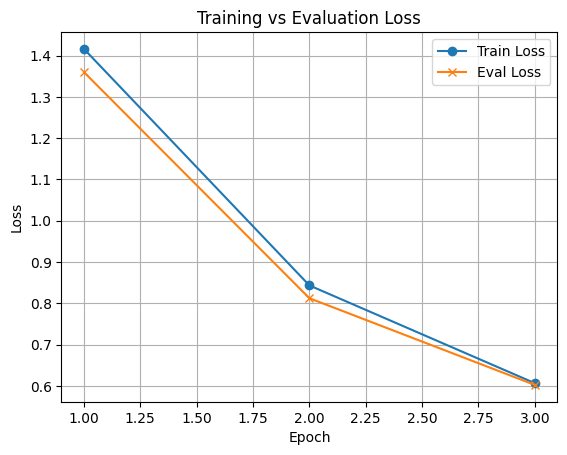

In [46]:
import matplotlib.pyplot as plt

figure, ax = plt.subplots()
ax.plot(epoch, loss, marker="o", label="Train Loss")
ax.plot(epoch, eval_loss, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [37]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

messages = [
    {"role": "user", "content": prompt}
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt"
)

inputs = {k: v.to(model.device) for k,v in inputs.items()} # This moves vectors to whatever device user is using

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=180,
        do_sample=False
    )
input_len = inputs["input_ids"].shape[1]
generated_ids = outputs[0][input_len:]
print(tokenizer.decode(generated_ids, skip_special_tokens=True))

{"tool": "search_flights", "arguments": {"origin": "San Diego", "destination": "New York", "departure_date": "2026-05-10", "return_date": "2026-05-15"}}


In [48]:
test_dataset["text"][0]

'<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nReturn ONLY valid JSON.\n\nAvailable tools:\n- search_flights(origin, destination, departure_date, return_date)\n- search_hotels(location, check_in_date, check_out_date)\n- plan_trip(destination, start_date, end_date, budget_level)\n- check_weather(location, date)\n\nUse exact tool names and exact argument keys.\n\nUser request:\nTravel request: I want an itinerary for London from 2026-05-10 to 2026-05-15 with high spending. Please respond with JSON only.<|im_end|>\n<|im_start|>assistant\n{"tool": "plan_trip", "arguments": {"destination": "London", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "HIGH"}}<|im_end|>\n'

In [49]:
import json
import pandas as pd

def evaluate_to_dataframe(model, tokenizer, dataset):
    rows = []
    systemish = """
    Return ONLY valid JSON.

    Available tools:
    - search_flights(origin, destination, departure_date, return_date)
    - search_hotels(location, check_in_date, check_out_date)
    - plan_trip(destination, start_date, end_date, budget_level)
    - check_weather(location, date)
    
    Use exact tool names and exact argument keys.
    
    User request:
    """
    for i, sample in enumerate(dataset):
        prompt = sample["messages"][0]["content"]
        reference = sample["messages"][1]["content"]

        pred = generate_tool(model, tokenizer, prompt)

        # defaults
        pred_tool = None
        pred_args = None
        actual_tool = None
        actual_args = None
        valid_json = False

        try:
            pred_json = json.loads(pred)
            valid_json = True
            pred_tool = pred_json.get("tool")
            pred_args = pred_json.get("arguments")
        except:
            pass

        try:
            ref_json = json.loads(reference)
            actual_tool = ref_json.get("tool")
            actual_args = ref_json.get("arguments")
        except:
            pass

        rows.append({
            "prompt": prompt,
            "pred_tool": pred_tool,
            "actual_tool": actual_tool,
            "tool_match": pred_tool == actual_tool,
            "pred_arguments": pred_args,
            "actual_arguments": actual_args,
            "arguments_match": pred_args == actual_args,
            "valid_json": valid_json,
            "prediction_raw": pred,
            "reference_raw": reference
        })

    df = pd.DataFrame(rows)
    return df

In [50]:
df = evaluate_to_dataframe(model, tokenizer, test_dataset)
df.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_flights,plan_trip,False,"{'origin': 'London', 'destination': 'London', ...","{'destination': 'London', 'start_date': '2026-...",False,True,"{""tool"": ""search_flights"", ""arguments"": {""orig...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",False,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'Honolulu', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""locatio...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,None,"{'location': 'New York', 'check_in_date': '202...",False,True,"{""tool"": ""search_hotels"", ""argument"": ""New Yor...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,weather_schemalike,check_weather,False,None,"{'location': 'Paris', 'date': '2026-08-21'}",False,True,"{""tool"": ""weather_schemalike"", ""argument_keys""...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [51]:
df.tool_match.value_counts()

tool_match
True     13
False     7
Name: count, dtype: int64

In [52]:
df.arguments_match.value_counts()

arguments_match
False    14
True      6
Name: count, dtype: int64

In [53]:
df.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

## Train mas

In [54]:
# Increase number of epochs
trainer.args.num_train_epochs = 6
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.281656,0.278587
2,0.188757,0.208579
3,0.174720,0.176413
4,0.150043,0.163497
5,0.153532,0.155090
6,0.139438,0.153166


TrainOutput(global_step=150, training_loss=0.20233072598775229, metrics={'train_runtime': 903.2706, 'train_samples_per_second': 0.664, 'train_steps_per_second': 0.166, 'total_flos': 250169887411200.0, 'train_loss': 0.20233072598775229})

## Model v2 Eval

In [55]:
epoch = []
loss = []
eval_loss = []

for log in trainer.state.log_history:
    if log["epoch"] % 1.0 == 0:
        if "loss" in log:
            epoch.append(log["epoch"])
            loss.append(log["loss"])
        elif "eval_loss" in log:
            eval_loss.append(log["eval_loss"])
        else:
            continue
        
print(epoch)
print(loss)
print(eval_loss)

[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
[0.28165574073791505, 0.18875737190246583, 0.1747200608253479, 0.15004255771636962, 0.15353195667266845, 0.1394381880760193]
[0.27858656644821167, 0.2085791379213333, 0.1764134019613266, 0.16349680721759796, 0.15509021282196045, 0.15316583216190338]


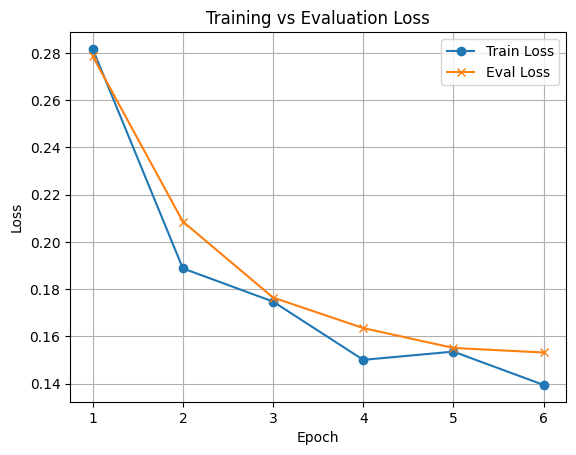

In [56]:
figure, ax = plt.subplots()
ax.plot(epoch, loss, marker="o", label="Train Loss")
ax.plot(epoch, eval_loss, marker="x", label="Eval Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Evaluation Loss")

ax.legend()
ax.grid()

plt.show()

In [57]:
prompt = """Return ONLY valid JSON.

Available tools:
- search_flights(origin, destination, departure_date, return_date)
- search_hotels(location, check_in_date, check_out_date)
- plan_trip(destination, start_date, end_date, budget_level)
- check_weather(location, date)

Use exact tool names and exact argument keys.

User request:
I want to go from San Diego to New York from 2026-05-10 to 2026-05-15 and keep it a medium budget."""

generate_tool(model, tokenizer, prompt)

'{"tool": "plan_trip", "arguments": {"destination": "New York", "start_date": "2026-05-10", "end_date": "2026-05-15", "budget_level": "MEDIUM"}}'

In [58]:
df_2 = evaluate_to_dataframe(model, tokenizer, test_dataset)
df_2.head()

,prompt,pred_tool,actual_tool,tool_match,pred_arguments,actual_arguments,arguments_match,valid_json,prediction_raw,reference_raw
0,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'London', 'start_date': '2026-...","{'destination': 'London', 'start_date': '2026-...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
1,Return ONLY valid JSON.\n\nAvailable tools:\n-...,plan_trip,plan_trip,True,"{'destination': 'Rome', 'start_date': '2026-09...","{'destination': 'Rome', 'start_date': '2026-09...",True,True,"{""tool"": ""plan_trip"", ""arguments"": {""destinati...","{""tool"": ""plan_trip"", ""arguments"": {""destinati..."
2,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'Honolulu', 'check_in_date': '202...","{'location': 'Honolulu', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
3,Return ONLY valid JSON.\n\nAvailable tools:\n-...,search_hotels,search_hotels,True,"{'location': 'New York', 'check_in_date': '202...","{'location': 'New York', 'check_in_date': '202...",True,True,"{""tool"": ""search_hotels"", ""arguments"": {""locat...","{""tool"": ""search_hotels"", ""arguments"": {""locat..."
4,Return ONLY valid JSON.\n\nAvailable tools:\n-...,check_weather,check_weather,True,"{'location': 'Paris', 'date': '2026-08-21'}","{'location': 'Paris', 'date': '2026-08-21'}",True,True,"{""tool"": ""check_weather"", ""arguments"": {""locat...","{""tool"": ""check_weather"", ""arguments"": {""locat..."


In [59]:
df_2.tool_match.value_counts()

tool_match
True    20
Name: count, dtype: int64

In [60]:
df_2.arguments_match.value_counts()

arguments_match
True    20
Name: count, dtype: int64

In [61]:
df_2.valid_json.value_counts()

valid_json
True    20
Name: count, dtype: int64

In [62]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
final_path = str(output_dir/"smollm-tool-routing-lora")
trainer.model.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")
tokenizer.save_pretrained(f"{final_path}/{ts}_final_adapter_v2")

('C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_003615_final_adapter_v2\\tokenizer_config.json',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_003615_final_adapter_v2\\chat_template.jinja',
 'C:\\Users\\Derrick\\OneDrive\\Desktop\\GIT\\model-alignment-lab\\outputs\\models\\smollm-tool-routing-lora/20260402_003615_final_adapter_v2\\tokenizer.json')